## NEGF Simulation of a Silicon Device

This notebook contains a basic tutorial on the use of Non-Equilibrium Green's functions for simulating the electronic transport properties of a Silicon slab-based P-I-N Photodiode

### Import Dependencies

This notebook requires a local installation of PyQUINN.

In [4]:
import pyquinn
import numpy as np
import torch
import matplotlib
import os
import pickle

### Configure Pytorch/CUDA:

Here you can (optionally) set the pytorch backend to use GPU instead of CPU:

In [5]:
import torch

if torch.cuda.is_available():
    print(f"Number of CUDA devices: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory allocated: {torch.cuda.memory_allocated(i) / 1e6:.2f} MB")
        print(f"  Memory reserved: {torch.cuda.memory_reserved(i) / 1e6:.2f} MB")
    print(f"Current device: {torch.cuda.current_device()}")
else:
    print("CUDA is not available")

CUDA is not available


In [6]:
# set to 'cpu' or any of the devices above
compute_device = 'cpu'

torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False

### Data Directory

In [7]:
DATA_DIR = './finalized_data'

## Part I: Loading the Pretrained Band Structure Model

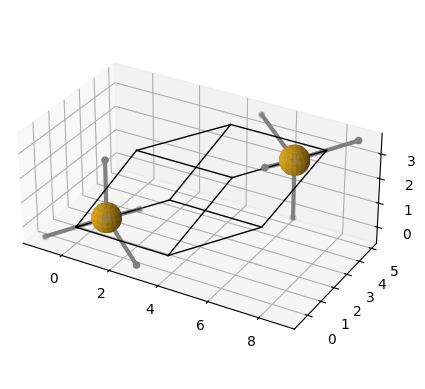

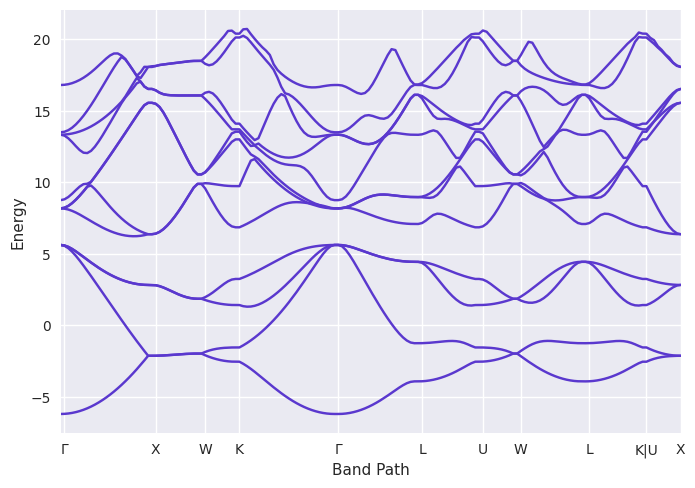

In [8]:
from pyquinn.types import AtomGraph, BandStructure

SI_GRAPH_NAME = 'mp-149_si_graph.pkl'

SI_BANDS_NAME = 'mp-149_si_bandpath_2.pkl'

si_graph = AtomGraph.load(os.path.join(DATA_DIR, SI_GRAPH_NAME))
si_bands = BandStructure.load(os.path.join(DATA_DIR, SI_BANDS_NAME))


fig1 = si_graph.plot()
fig2 = si_bands.plot_band_path(atoms=si_graph)

In [9]:
from pyquinn.types import BandStructureDataset

si_dataset = BandStructureDataset()
si_dataset.append(si_graph, si_bands)

si_cutoffs = {
    'Si': 8.0, # interaction cutoff at 8 Angstroms
}

torch_si_warmup_dataset = si_dataset.compile(
    backend='torch', 
    cutoffs=si_cutoffs, # interaction cutoff at 8 Angstroms
    max_k_pts=40
)

torch_si_finetune_dataset = si_dataset.compile(
    backend='torch', 
    cutoffs=si_cutoffs,  # interaction cutoff at 8 Angstroms
    max_bands=5,         # only fine-tune on valence bands + 1 conduction band
    max_k_pts=40,
)

 100%|████████████████████████████████████████████████████████████████████████████████| 1/1 
 100%|████████████████████████████████████████████████████████████████████████████████| 1/1 


Next, we will create a very basic tight binding model with constant orbtial parameters and pseudopotential (i.e. no neural network parameterization). We do this using the `torch` backend's `TBHamiltonian` object. We can then build a trainable model using the wrapper class `TorchBandStructureModel`:

In [10]:
from pyquinn.torch.models import TorchBandStructureModel
from pyquinn.torch.nn.lcao import TBHamiltonian

tb_hamiltonian = TBHamiltonian(
    basis_size=3,
    potential_basis_size=3
)
torch_model = TorchBandStructureModel(tb_hamiltonian)

In the interest of time, we will load the weights of a pretrained model; however, you can train the model from scratch using the following two cells. Note that training on a laptop CPU may be very slow.

In [11]:
# history = torch_model.fit(
#     torch_si_warmup_dataset, 
#     lr=0.05,
#     use_projections=True,
#     projection_weight=10.0,
#     epochs=500,
#     verbosity=1)

In [12]:
# finetune_history = torch_model.fit(
#     torch_si_finetune_dataset,
#     lr=0.05,
#     use_projections=False,
#     epochs=50,
#     verbosity=1)

This cell loads the state dictionary of our model containing pretrained weights:

In [13]:
#torch.save(torch_model, './si_3g_conduction_statedict.pt')

In [14]:
torch_model = torch.load('./si_3g_conduction_statedict.pt', weights_only=False)\
    .to(torch.get_default_device())

## Part II: Validating the Pretrained Model

Next, let's plot the band structure predicted by our pretrained QuINN model and compare it to the band structure we retrieved from the MaterialsProject database. To obtain the predicted band structure, we must first convert our retrieved `AtomGraph` and `BandStructure` to the corresponding Pytorch datatypes. We do this with the `compile()` function, passing in the appropriate cutoff radii. We then obtain the band structure using `TorchBandStructureModel.predict()` function:

/ion/home/burdinec/git/pyquinn/src/pyquinn/torch/util.py:152: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  return torch.sparse_coo_tensor(


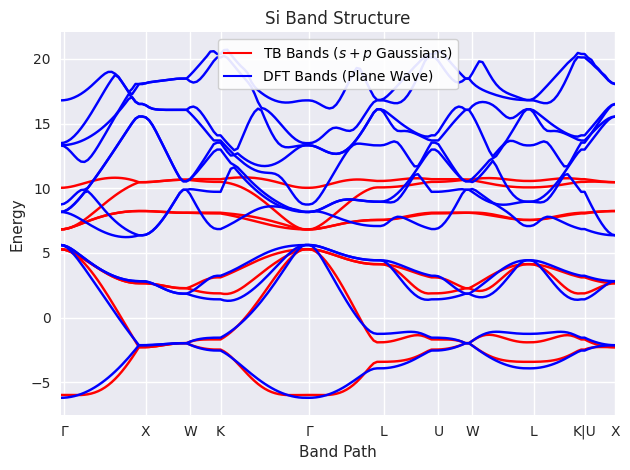

In [15]:
import matplotlib.pyplot as plt

torch_graph = si_graph.compile(
    backend='torch', 
    cutoffs={'Si': 4.0},
    device=torch.get_default_device()
)

torch_bands = si_bands.compile(
    backend='torch',
    device=torch.get_default_device()
)

torch_pred_bands = torch_model.predict(torch_graph, k_pts=torch_bands.k_pts)

fig = plt.figure()
torch_pred_bands.plot_band_path(atoms=torch_graph, color='r', fig=fig, show=False)
torch_bands.plot_band_path(atoms=torch_graph, color='b', fig=fig, show=False)
plt.plot([], color='r', label='TB Bands ($s+p$ Gaussians)')
plt.plot([], color='b', label='DFT Bands (Plane Wave)')
plt.title('Si Band Structure')
plt.legend(loc='upper center', framealpha=0.9)
plt.tight_layout()
plt.show()

In addition to computing the band structure, the QuINN model by default also returns the projections onto local orbitals for each atomic site, which are accessible using the `projections` attribute of a `BandStructure` object predicted by a model: 

E_gap: [1.5361247]


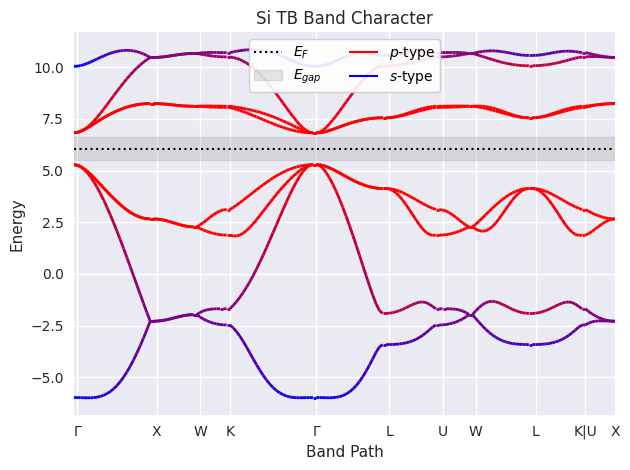

In [16]:
# Obtain a BandStructure object from the TorchBandStructure object
si_pred_bands = torch_pred_bands.extract()

# compute fermi energy
E_fermi = si_pred_bands.idos_level(
    n=8 - 1e-5,   # 8 electrons per unit cell 
                  # (minus small number to put E_f at bottom)
    band_mult=2,  # spin paired,
    sigma=1e-5,   # very little smearing,
    max_evals=100
)

E_gap = si_pred_bands.band_gap(
    energy=E_fermi + 0.5,
)
print('E_gap:', E_gap)

# extract s and p band orbital projections
s_projs = si_pred_bands.projections[...,:1].sum((-2,-1))
p_projs = si_pred_bands.projections[...,1:4].sum((-2,-1))
orb_projs = np.stack([ s_projs, p_projs ], axis=-1)

# plot orbital character of bands:
fig = plt.figure()
    
fig = si_pred_bands.plot_band_path(
    atoms=si_graph,
    show=False,
    proj_color_map=['blue', 'red'],
    proj_color_weights=np.stack([ s_projs, p_projs ], axis=-1),
    proj_color_labels = ['S Bands', 'P Bands'],
    fig=fig,
)

plt.axhline(E_fermi + E_gap/2, color='k', linestyle=':', label=r'$E_F$')
plt.axhspan(E_fermi.item()+0.2, E_fermi.item() + E_gap.item()-0.2, color='gray', alpha=0.2,label=r'$E_{gap}$')

plt.plot([],[],'r', label=r'$p$-type')
plt.plot([],[],'b', label=r'$s$-type')


#plt.ylim((-7.5, 12))
plt.title('Si TB Band Character')
plt.legend(loc='upper center', ncol=2, framealpha=0.9)
plt.tight_layout()
plt.show()

## Part III: Building a Silicon Bulk Device for NEGF simulation

We will start by building a diamond-structured silicon cubic unit cell, which will make building the device easier. We will use ASE's `bulk()` function to create it with the correct lattice constant:

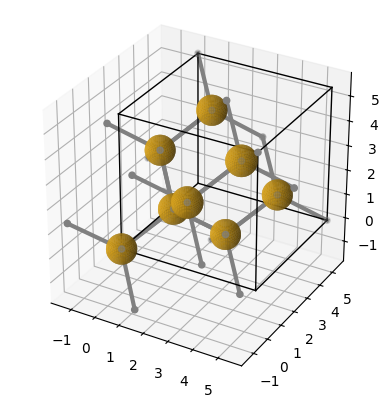

<Figure size 640x480 with 0 Axes>

In [17]:
from pyquinn.types import AtomGraph
from ase.build import bulk

si_cubic_graph = AtomGraph.from_ase(bulk('Si', 'diamond', cubic=True))
fig = si_cubic_graph.plot(atom_resolution=64)
plt.tight_layout()
fig.show()


Next, we will create the leads by expanding the cubic unit cell into a 1x2x2 unit, which we will use for the leads. We will then make a 4x2x2 unit for the nanobeam and set the periodicity conditions appropriately. When constructing the beam, we will have options to add random vacant sites to simulate the effects of defects in the device.

Note that even though the leads are semi-infinitely periodic along the x-axis, we will build them as if they are periodic along the x-axis for now.

In [18]:
si_block = si_cubic_graph.supercell([1,1,1])

device_blocks = 16 # <-- Here, we use a reduce-sized device. You can increase up to full size (45 blocks), if desired.
smoothing_blocks = 4 # <-- These are the number of cells over which the electric field is smoothed.

# build left lead (pristine):
lead_1 = si_block.copy()
lead_1.positions -= 1*si_block.unit_cell[0]
lead_1.periodic = (True, True, True)

# build right lead (pristine):
lead_2 = si_block.copy()
lead_2.positions += device_blocks*si_block.unit_cell[0]
lead_2.periodic = (True, True, True)

# build device region
device = si_block.copy().supercell([device_blocks,1,1])
device.periodic = (False, True, True)

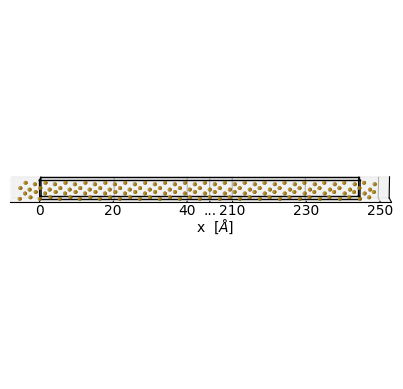

In [19]:
# plot figure
fig = plt.figure()
lead_1.plot(atom_resolution=10, hide_bonds=True, hide_unit_cell=True, fig=fig, show=False)
device.plot(atom_resolution=10, hide_bonds=True, fig=fig, show=False)
lead_2.plot(atom_resolution=10, hide_bonds=True, hide_unit_cell=True, fig=fig, show=False)
#plt.plot([],[], 'k', label='Device region')
#plt.gca().set_box_aspect((10, 1, 1)) 
plt.gca().view_init(elev=10, azim=-90)
plt.gca().set_yticks([])
plt.gca().set_zticks([])

# These lines label the device dimensions as if it is full size (comment out if desired):
L = float(device.unit_cell[0,0] + si_block.unit_cell[0,0])
L_real = 250
plt.gca().set_xticks([0, 20, 40, L/2, L-40, L-20, L])
plt.gca().set_xticklabels([0, 20, 40, '...', L_real-40, L_real-20, L_real])


plt.gca().text2D(0.5, 0.4, r"x  [$\AA$]", transform=plt.gca().transAxes)
#plt.legend(loc='upper right')
plt.xlim(-8, L+3)
plt.show()

*Note*: We compile each device graph using a short cutoff radius (3.0 Å) for computational efficiency. When increasing the cutoff radius, increasing the size of the lead unit cell may be necessary to avoid second-nearest-neighbor cell coupling in the leads. Only first-nearest neighbor coupling is allowed when solving for surface Green's functions.

In [20]:
import torch

# clear device unit cell:
device_length = float(device.unit_cell[0,0])
print('Length:', device_length)


smoothing_length = float(si_block.unit_cell[0,0]*smoothing_blocks)
print('Smoothing length:', smoothing_length)

device.unit_cell[0] = 0.0
device_cutoffs = {
    'Si': 3.0
}


torch_lead_1 = lead_1.compile('torch', cutoffs=device_cutoffs, device=torch.get_default_device())
torch_lead_2 = lead_2.compile('torch', cutoffs=device_cutoffs, device=torch.get_default_device())
torch_device = device.compile('torch', cutoffs=device_cutoffs, device=torch.get_default_device())

Length: 86.88
Smoothing length: 21.72


*Note*: We will build the NEGF calculation setup using the `TorchNEGF` object. This object supports an arbitrary number of leads. For each lead, a semi-infinite boundary orientation must be specified, which indicates the direction (with respect to to the lead lattice vectors) in which the lead is semi-infinite.

In [21]:
from pyquinn.torch.analysis.negf import TorchNEGFDevice

torch_negf = TorchNEGFDevice(
    device=torch_device,
    leads=[
        torch_lead_1,
        torch_lead_2
    ],
    orientations=[
        torch.tensor([ -1, 0, 0]), # lead 1 is semi-infinite in the -x direction
        torch.tensor([  1, 0, 0]), # lead 2 is semi-infinite in the +x direction
    ])

E_negf = torch.linspace(-5, 10.0, 128)
k_negf_hires = torch_device.band_path()
k_negf = k_negf_hires[::len(k_negf_hires)//32]

# set the effective fermi level
fermi_level = torch.tensor(E_fermi + E_gap/2).squeeze()


## Part IV: NEGF Band Calculations

In [1]:
from pyquinn.torch.analysis.negf import (
    NEGFSolver,
    ImpactIonizationScatterer,
    PhotonDipoleScatterer,
    EinsteinPhononScatterer,
    ElasticDephasingScatterer
)

In [22]:
from pyquinn.torch.analysis.negf import TorchNEGFResult

solver = NEGFSolver(
    torch_negf,
    model=torch_model,
    tol=1e-6,
    k_batch_size=1,
)
# introduce scattering sources
scatterers = [
    ImpactIonizationScatterer(D_ionization=1.0, valence_cutoff=fermi_level),
]

# Note: This calculation may require at around 15-20 Gb of RAM
#       to hold all tensors in memory.
with torch.no_grad():
    negf_result = solver.solve(
        E_negf,
        k_pts=k_negf,
        eta=1e-2,
        scatterers=scatterers,
        verbosity=2,
        cache_dir='./negf_workdir/negf_bands/', # <-- Set a cache directory to run the calculation in k-point batches (conserves VRAM)
        chemical_potentials=[fermi_level, fermi_level]
    )



Computing device Hamiltonian.
Solving device Green's function.
Solving self-consistent scattering contributions.
SCBA (batch: 31, iter: 0, err: 0.000000e+00, alpha: 0.1) [Converged]


In [24]:
# optional: load the negf result from a cached result:
negf_result = TorchNEGFResult.load('./negf_workdir/negf_bands/')

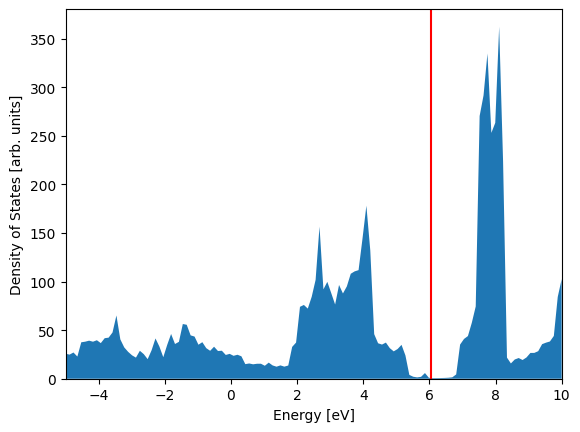

In [25]:
plt.figure()
plt.fill_between(
    E_negf.cpu().detach().numpy(), 
    negf_result.dos(band_mult=2).cpu().detach().numpy())
#plt.plot(E_dos, negf_result.dos(), color='k')
plt.axvline(fermi_level.item(), color='r', label=r'$E_F$')
plt.ylim((0,None))
plt.xlim((E_negf.min().item(), E_negf.max().item()))
plt.ylabel('Density of States [arb. units]')
plt.xlabel('Energy [eV]')
plt.show()

In [26]:
torch_model.to('cpu')
si_slab_bands = torch_model.predict(torch_lead_1.to('cpu'), k_negf_hires.cpu()).extract()
si_slab_bands.energies -= fermi_level.cpu().item()

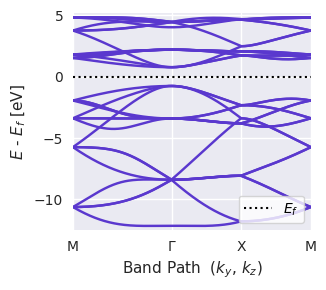

In [27]:
fig = plt.figure(figsize=(3.5,3))
fig = si_slab_bands.plot_band_path(atoms=torch_device, fig=fig, show=False)
E_pad = (si_slab_bands.energies.max() - si_slab_bands.energies.min()) * 0.02
E_range = (si_slab_bands.energies.min()-E_pad, si_slab_bands.energies.max()+E_pad)
plt.axhline(0, linestyle=':', color='k', label=r'$E_f$')
plt.ylim(E_range)
plt.legend(loc='lower right')
plt.xlabel(r'Band Path  ($k_y$, $k_z$)')
plt.ylabel('$E$ - $E_f$ [eV]')
plt.tight_layout()
plt.show()

prev_fig = fig
prev_band_folds = [item.get_text() for item in prev_fig.axes[0].get_xticklabels()]

In [28]:
broadened_bs = negf_result.dos(band_mult=2.0, k_resolved=True) / device_blocks

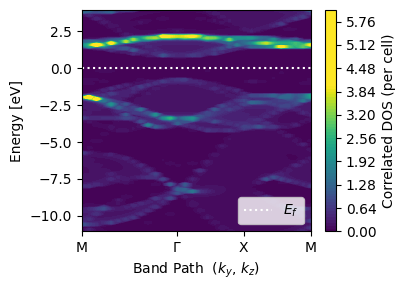

In [29]:

k_x = np.linspace(0, len(k_negf_hires)-1, len(k_negf))
K, E = np.meshgrid(k_x, E_negf.cpu().detach().numpy())

fig = plt.figure(figsize=(4,3))
cm = plt.contourf(K, E-fermi_level.item(), np.minimum(broadened_bs.cpu().detach().numpy().T / device_blocks, 8), vmax=4, levels=100)
cm.set_edgecolor("face")
#si_slab_bands.plot_band_path(backend='mpl', atoms=torch_device, fig=fig, show=False, color='r')
plt.gca().set_xticks(prev_fig.axes[0].get_xticks())
plt.gca().set_xticklabels(prev_band_folds)
#plt.gca().set_yticks(prev_fig.axes[0].get_yticks())
plt.axhline(0, linestyle=':', color='w', label=r'$E_f$')
cbar = plt.colorbar(cm, label='Correlated DOS (per cell)')
#plt.ylim(())
plt.legend(loc='lower right')
plt.xlabel(r'Band Path  ($k_y$, $k_z$)')
plt.ylabel('Energy [eV]')
plt.tight_layout()
plt.show()

## Part V: Modeling the P-I-N Photodiode Device

In [32]:
T = 300             # [K]
k = 8.617333262e-5 # [eV / K]
kt = k*T # [eV]

L_device = torch.tensor(device_length)
lambda_device = torch.tensor(smoothing_length)

# log_N_p = torch.log(torch.tensor(2.5))\
#     + torch.log(torch.tensor(10))*18 # 2.5e18 [cm^{-3}]
# log_N_n = torch.log(torch.tensor(4.0))\
#     + torch.log(torch.tensor(10))*18 # 4.0e18 [cm^{-3}]
# log_n_i = torch.log(torch.tensor(2.0))\
#     + torch.log(torch.tensor(10))*16 # 2.0e16 [cm^{-3}]

log_N_p = torch.log(torch.tensor(2.5e18))
log_N_n = torch.log(torch.tensor(4.0e18))
log_n_i = torch.log(torch.tensor(2.0e16))

# recommended i ~ 200 nm = 2,000 A 
# (for testing, we'll make it much smaller)

# V_bi = (kT/q) log( N_a N_d / n_i^2 )

apd_fermi_level = fermi_level.clone()
dE_p = kt*(log_N_p - log_n_i)
dE_n = -kt*(log_N_n - log_n_i)


#---------------------------------------------------------------
# Simulation voltage bias parameters:
V_bias_max = -5.0
V_bias_test = 0.0
#---------------------------------------------------------------


def U_device(x, V=0):
    x = x[:, 0]

    U_left  = dE_p - V / 2
    U_right = dE_n + V / 2

    x_L = 0
    x_R = L_device
    lam = lambda_device

    # Require 0 < lam < x_R - x_L
    F = (U_right - U_left) / (x_R - x_L - lam)

    U_left_flat = torch.full_like(x, U_left)
    U_right_flat = torch.full_like(x, U_right)

    # left smoothing region: x_L < x < x_L + lam
    U_left_smooth = U_left + F / (2 * lam) * (x - x_L)**2

    # central linear region: x_L + lam <= x <= x_R - lam
    U_linear = U_left + F * (x - x_L - lam / 2)

    # right smoothing region: x_R - lam < x < x_R
    U_right_smooth = U_right - F / (2 * lam) * (x_R - x)**2

    return torch.where(
        x <= x_L,
        U_left_flat,
        torch.where(
            x < x_L + lam,
            U_left_smooth,
            torch.where(
                x <= x_R - lam,
                U_linear,
                torch.where(
                    x < x_R,
                    U_right_smooth,
                    U_right_flat,
                ),
            ),
        ),
    )

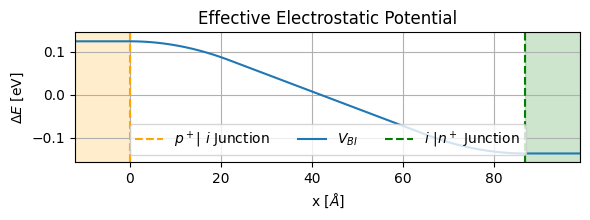

In [34]:
x = torch.zeros((100,3))
x[:,0] = torch.linspace(-12, L_device+12, x.shape[0])

V_curve = U_device(x, V_bias_test).cpu().detach().numpy()
x_pts = x[:,0].cpu().detach().numpy()
y_pad = 0.08*(V_curve.max() - V_curve.min())
y_range = (V_curve.min()-y_pad, V_curve.max()+y_pad)

plt.figure(figsize=(6,2.3))

plt.fill_betweenx(y_range, [x_pts.min()]*2, [0]*2, color='orange', alpha=0.2)
plt.axvline(0, linestyle='--', color='orange', label=r'$p^+$|$~i$ Junction')

plt.plot(
    x_pts,
    V_curve,
    label=r'$V_{BI}$')

plt.fill_betweenx(y_range, [x_pts.max()]*2, [L_device.item()]*2, color='g', alpha=0.2)
plt.axvline(L_device.item(), linestyle='--', color='g', label=r'$i~$|$n^+$ Junction')
plt.xlabel(r'x [$\AA$]')
plt.ylabel(r'$\Delta E$ [eV]')
plt.ylim(y_range)
plt.xlim(x_pts.min(), x_pts.max())
plt.grid()
plt.legend(loc='lower center', ncol=3)
plt.title('Effective Electrostatic Potential')
plt.tight_layout()
plt.show()

In [51]:
apd_torch_negf = TorchNEGFDevice(
    device=torch_device.to(compute_device),
    leads=[
        torch_lead_1.to(compute_device),
        torch_lead_2.to(compute_device)
    ],
    orientations=[
        torch.tensor([ -1, 0, 0]).to(compute_device), # lead 1 is semi-infinite in the -x direction
        torch.tensor([  1, 0, 0]).to(compute_device), # lead 2 is semi-infinite in the +x direction
    ],
    device_potential=U_device(torch_device.positions, V_bias_test).to(compute_device),
    lead_potentials=[
        U_device(lead.positions, V_bias_test).to(compute_device)
        for lead in (torch_lead_1, torch_lead_2)
    ]
)

apd_solver = NEGFSolver(
    apd_torch_negf,
    model=torch_model.to(compute_device),
    tol=1e-3,
    k_batch_size=1,
    mixing_alpha = 0.1,
    max_iter=1024
)

apd_site_indices, _ = apd_solver.model.orbital_indices(torch_device.to(compute_device))
orbital_valence_cutoffs = (fermi_level + \
    apd_torch_negf.device_potential[apd_site_indices])

apd_scatterers = [
    ImpactIonizationScatterer(
        D_ionization=1e-2, 
        valence_cutoff=orbital_valence_cutoffs)
]

apd_k_pts = torch_device.unit_rcell_mesh((1,5,5)) # <-- This can be increased up to a 1 x 9 x 9 mesh

In [52]:
E_window = torch.linspace(0, 10, 512)

with torch.no_grad():
    apd_lead_gfs = solver.solve_lead_greens_functions(
        E_window.to(compute_device),
        eta=5e-3,
        k_pts=apd_k_pts.to(compute_device),
        verbosity=2)

    apd_lead_dos = []
    for gf in apd_lead_gfs:
        gf = gf.cpu()
        dos = (-1/torch.pi)*torch.diagonal(gf.imag, dim1=-2, dim2=-1).sum(dim=(-3, -1))
        apd_lead_dos.append(dos)

Solving surface Green's function (lead 0).
Sancho Rubio (batch: 24, iter: 10, eta: 5.000000e-03, err: 3.930077e-05) [Converged]
Solving surface Green's function (lead 1).
Sancho Rubio (batch: 24, iter: 10, eta: 5.000000e-03, err: 3.916734e-05) [Converged]


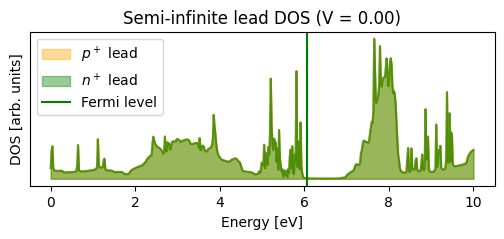

In [53]:
plt.figure(figsize=(6,2))
plt.plot(E_window, apd_lead_dos[0].detach().numpy(), color='orange', alpha=0.6)
plt.fill_between(E_window, apd_lead_dos[0].detach().numpy(), color='orange', alpha=0.4, label=r'$p^+$ lead')
plt.plot(E_window, apd_lead_dos[1].detach().numpy(), color='g', alpha=0.6)
plt.fill_between(E_window, apd_lead_dos[1].detach().numpy(), color='g', alpha=0.4, label=r'$n^+$ lead')
plt.xlabel('Energy [eV]')
plt.ylabel('DOS [arb. units]')
plt.axvline(fermi_level, color='g', label='Fermi level')
plt.yticks([])
plt.legend()
plt.title(f'Semi-infinite lead DOS (V = {V_bias_test:.2f})')
plt.show()

In [54]:
# Note: This calculation may require at around 15-20 Gb of RAM
#      to hold all tensors in memory.

# torch.cuda.empty_cache()

with torch.no_grad():
    apd_result = apd_solver.solve(
        E_negf.to(compute_device),
        k_pts=apd_k_pts.to(compute_device),
        eta=5e-3,
        kt=kt,
        scatterers=apd_scatterers,
        verbosity=2,
        cache_dir='./negf_workdir/negf_transmission',
        chemical_potentials=[
            fermi_level.to(compute_device)+V_bias_test/2+dE_p, 
            fermi_level.to(compute_device)-V_bias_test/2+dE_n
        ]
    )

Computing device Hamiltonian.


KeyboardInterrupt: 

In [ ]:
# compute transmission spectrum across lead:
T_apd = apd_result.coherent_transmission(0,1, band_mult=2).squeeze().cpu()

In [ ]:
#apd_result = TorchNEGFResult.load('./data/si_apd_test_large_iie')

In [ ]:
n_blocks = device_blocks
x_block_size = si_block.unit_cell[0,0]
x_block_grid = (0.5 + np.arange(n_blocks))*x_block_size
X, E = np.meshgrid(x_block_grid, E_negf.detach().numpy())

x_mesh = torch.linspace(0, L_device.item(), 1000)
xyz_mesh = torch.vstack((x_mesh, torch.zeros_like(x_mesh), torch.zeros_like(x_mesh))).T
y_valence = (fermi_level - torch.tensor(E_gap)/2) + U_device(xyz_mesh, V_bias_test)
y_conduction = y_valence + torch.tensor(E_gap)

device_position_blocks = (apd_torch_negf.device.positions[:,0] // x_block_size).to(torch.int32)
apd_site_indices, _ = apd_solver.model.orbital_indices(apd_solver.negf_device.device.to(compute_device))
device_orbital_blocks = device_position_blocks[apd_site_indices].cpu()

# construct block-resolved ldos:
apd_ldos = apd_result.ldos().cpu()
device_block_ldos = torch.zeros(E_negf.shape[0], n_blocks, device=apd_ldos.device)
device_block_ldos.scatter_add_(
    1, 
    device_orbital_blocks.unsqueeze(0).expand(apd_ldos.shape),
    apd_ldos)

# plot block-resolved dos:

plt.figure(figsize=(5,4))
cm = plt.pcolormesh(X,E-fermi_level.item(), device_block_ldos.cpu().detach().numpy())
plt.colorbar(cm, label='Local Density of States')
plt.axhline(0, color='w', linestyle=':', label=r'$E_f$')
plt.xlabel(r'x [$\AA$]')
plt.ylabel('$E$ - $E_F$ [eV]')
plt.plot(x_mesh,y_conduction-fermi_level.item(), 'w', label='$E_c/E_v$')
plt.plot(x_mesh,y_valence-fermi_level.item(), 'w')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [ ]:
apd_occ_ldos = apd_result.occupied_ldos().cpu()

device_block_occ_ldos = torch.zeros(E_negf.shape[0], n_blocks)
device_block_occ_ldos.scatter_add_(
    1, 
    device_orbital_blocks.unsqueeze(0).expand(apd_occ_ldos.shape), 
    apd_occ_ldos)

plt.figure(figsize=(5,4))
cm = plt.pcolormesh(X,E-fermi_level.item(), device_block_occ_ldos.detach().numpy())
plt.colorbar(cm, label='Density of Occupied States')
plt.axhline(0, color='w', linestyle=':', label=r'$E_i$')
plt.xlabel(r'x [$\AA$]')
plt.ylabel('$E$ - $E_f$ [eV]')
plt.plot(x_mesh,y_conduction-fermi_level.item(), 'w', label='$E_c/E_v$')
plt.plot(x_mesh,y_valence-fermi_level.item(), 'w')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Run Bias-Dependent Simulations


In [ ]:
import tempfile
import pickle as pkl
import datetime

V_bias_values = np.linspace(0, V_bias_max, 3)
I_bias_values = []
I_coherent_bias_values = []
N_bias_values = []
DOS_bias_values = []
Converged = []

apd_solver.mixing_alpha = 0.1
apd_solver.mixing_alpha_min = 1e-7



torch_model.to(compute_device)

D_device = 1e-3

with torch.no_grad():
    biased_apd_result = None
    for _V_bias in V_bias_values:
        with tempfile.TemporaryDirectory() as tmpdir:
            #try:
                biased_apd_result = apd_solver.solve(
                    E_negf.to(compute_device),
                    k_pts=apd_k_pts.to(compute_device),
                    eta=5e-3,
                    kt=kt,
                    scatterers=[
                        ImpactIonizationScatterer(
                           D_ionization=D_device, 
                           valence_cutoff=orbital_valence_cutoffs)
                    ],
                    verbosity=2,
                    chemical_potentials=[fermi_level+_V_bias/2, fermi_level-_V_bias/2],
                    cache_dir=None
                )
        
                torch.cuda.empty_cache()
        
                I_bias_values.append( biased_apd_result.current(0, 1, band_mult=2).cpu() )
                I_coherent_bias_values.append( biased_apd_result.coherent_current(0, 1, band_mult=2).cpu() )
    
                N_bias_values.append( biased_apd_result.occupied_ldos(band_mult=2).cpu() )
                DOS_bias_values.append( biased_apd_result.ldos(band_mult=2).cpu() )
                Converged.append(True)
                
            #except:
            #    print('FAILED TO CONVERGE')
            #    Converged.append(False)

result_dict = {
    'D_device': D_device,
    'Blocks': np.array(device_orbital_blocks),
    'V_bias_values': np.array(V_bias_values),
    'I_bias_values' : np.array(I_bias_values),
    'I_coherent_bias_values' : np.array(I_coherent_bias_values),
    'Converged': np.array(Converged)
}

time_str = str(datetime.datetime.now()).replace(' ', '-')

with open(os.path.join(FIG_DIR, f'ivdata_{time_str}.pkl'), 'wb') as f:
    pkl.dump(result_dict, f)